### Validation Notebook

**Changes from original:**
1. **Dataset pivoting** — reshapes long-format (multiple rows per date) to wide format (one row per date, weather columns suffixed by location)
2. **Spread fix** — triple barrier now uses the ECM residual spread (with hedge ratio beta), not the raw log-ratio
3. **`get_bins` fix** — vertical barrier (time-out) now correctly labelled 0 instead of +1/-1
4. **Vertical barrier edge case** — last rows clipped safely instead of silently dropped
5. **Cleanup** — removed unused `pt_sl_` variable in `get_events`

## Step 0 — Load dataset & transform to wide format

We have all the weather variables 3 times (for 3 different locations), so we have 3 rows with the same date. We need to change the dataframe so there is 1 row for each unique date only(for the model to work correctly).

In [51]:
import pandas as pd
import numpy as np

# Load data
raw = pd.read_csv(r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\merged_prices_weather.csv")

raw['date'] = pd.to_datetime(raw['date'])

# Identify column groups (price is equal across locations, so we can separate it from location-specific weather)
price_cols   = ['corn_Close', 'corn_Volume', 'corn_log_return',
                'soybean_Close', 'soybean_Volume', 'soybean_log_return']
meta_cols    = ['date', 'Latitude', 'Longitude', 'Location_ID']
weather_cols = [c for c in raw.columns if c not in price_cols + meta_cols]

# Price table: one row per date (prices are identical across locations)
prices = (
    raw.groupby('date')[price_cols]
       .first()
       .reset_index()
)

# Weather table: pivot to wide format(one row per date, separate columns for each location)
raw_weather = raw.dropna(subset=['Location_ID']).copy()
raw_weather['Location_ID'] = raw_weather['Location_ID'].astype(int)
weather_wide = raw.pivot(index='date', columns='Location_ID', values=weather_cols)
weather_wide.columns = [f"{var}_loc{loc}" for var, loc in weather_wide.columns]
weather_wide = weather_wide.reset_index()

# Merge
data = prices.merge(weather_wide, on='date')

# Set date index & deduplicate
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data = data[~data.index.duplicated(keep='first')]
data = data.sort_index()

print(f"Wide dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} → {data.index.max().date()}")
print(f"Columns ({len(data.columns)} total):")
print(data.columns.tolist()[:10], "...")  # preview first 10
data.head(3)

Wide dataset shape: (5305, 162)
Date range: 2005-01-03 → 2026-02-02
Columns (162 total):
['corn_Close', 'corn_Volume', 'corn_log_return', 'soybean_Close', 'soybean_Volume', 'soybean_log_return', 'temperature_2m_mean_locnan', 'temperature_2m_mean_loc1.0', 'temperature_2m_mean_loc2.0', 'temperature_2m_mean_loc3.0'] ...


,corn_Close,corn_Volume,corn_log_return,soybean_Close,soybean_Volume,soybean_log_return,temperature_2m_mean_locnan,temperature_2m_mean_loc1.0,temperature_2m_mean_loc2.0,temperature_2m_mean_loc3.0,...,soil_temperature_0_to_7cm_mean_loc2.0,soil_temperature_0_to_7cm_mean_loc3.0,soil_temperature_28_to_100cm_mean_locnan,soil_temperature_28_to_100cm_mean_loc1.0,soil_temperature_28_to_100cm_mean_loc2.0,soil_temperature_28_to_100cm_mean_loc3.0,soil_temperature_7_to_28cm_mean_locnan,soil_temperature_7_to_28cm_mean_loc1.0,soil_temperature_7_to_28cm_mean_loc2.0,soil_temperature_7_to_28cm_mean_loc3.0
date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,201.75,1743.0,0.000000,537.25,47,0.000000,NaN,11.580083,9.055416,6.513833,...,10.184585,5.168000,NaN,5.542584,13.367916,6.813833,NaN,8.771749,10.949168,5.303416
2005-01-04,201.00,1357.0,-0.003724,529.75,54,-0.014058,NaN,4.525917,7.024166,8.643000,...,8.736667,7.170083,NaN,6.175917,13.167916,6.861749,NaN,7.267583,10.107500,6.636750
2005-01-05,201.50,1159.0,0.002484,534.00,37,0.007991,NaN,0.390500,7.551250,5.203417,...,8.428333,4.782584,NaN,6.390499,12.880416,6.942999,NaN,5.090500,9.442917,5.793000


## Step 1 — Estimating Beta & Cointegration Test & Hedge Ratio

Estimating beta with 1-year rolling window (no look-ahead bias)...
Window size: 252 trading days

Total rows available: 5303
✓ Beta estimation complete. First 252 rows have NaN (insufficient history).

BETA STATISTICS (Rolling 1-Year Window)
Mean:   0.8609
Median: 0.7791
Std:    0.5941
Min:    -0.1755
Max:    2.9376
Range:  3.1131

COINTEGRATION TEST (on rolling-window spread)
ADF Statistic: -5.6128
P-Value:       0.00000
Result: COINTEGRATION DETECTED — spread is mean-reverting ✓


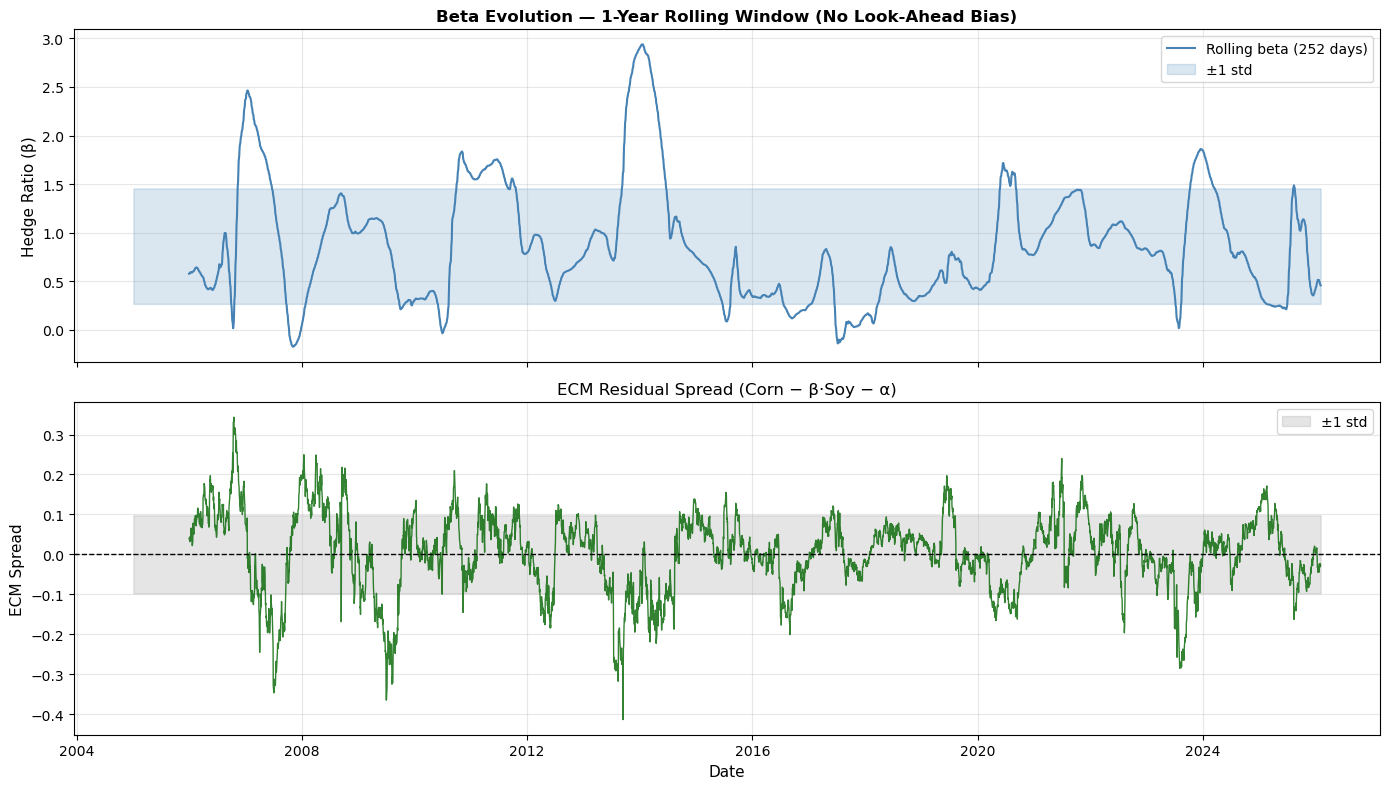

In [52]:
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Rolling Window Beta Estimation

WINDOW = 252  # 1 trading year

print("Estimating beta with 1-year rolling window (no look-ahead bias)...")
print(f"Window size: {WINDOW} trading days\n")

# Prepare log prices
log_corn = np.log(data['corn_Close'])
log_soy = np.log(data['soybean_Close'])

# Drop any NaNs or zeros
valid_idx = (data['corn_Close'] > 0) & (data['soybean_Close'] > 0)
log_corn = log_corn[valid_idx]
log_soy = log_soy[valid_idx]

print(f"Total rows available: {len(log_corn)}")

# Initialize results
data['beta'] = np.nan
data['alpha'] = np.nan
data['ecm_spread'] = np.nan

# Rolling window estimation
for i in range(WINDOW, len(log_corn)):
    # Training window: PAST 252 days (not including current day; no look-ahead)
    train_log_corn = log_corn.iloc[i-WINDOW:i]
    train_log_soy = log_soy.iloc[i-WINDOW:i]
    
    # Estimate beta and alpha on training window
    X = sm.add_constant(train_log_soy)
    try:
        ols = sm.OLS(train_log_corn, X).fit()
        beta_t = ols.params.iloc[1]  # FIX: use iloc[1] for slope
        alpha_t = ols.params.iloc[0]  # FIX: use iloc[0] for intercept
    except:
        # If OLS fails, use previous values
        beta_t = data['beta'].iloc[i-1] if i > WINDOW else np.nan
        alpha_t = data['alpha'].iloc[i-1] if i > WINDOW else np.nan
    
    # Store parameters for this date
    current_idx = log_corn.index[i]
    data.loc[current_idx, 'beta'] = beta_t
    data.loc[current_idx, 'alpha'] = alpha_t
    
    # Compute spread using beta/alpha from PAST data only
    data.loc[current_idx, 'ecm_spread'] = (
        log_corn.iloc[i] - beta_t * log_soy.iloc[i] - alpha_t
    )

print(f"✓ Beta estimation complete. First {WINDOW} rows have NaN (insufficient history).\n")

# Summary Statistics

valid_beta = data['beta'].dropna()

print("=" * 80)
print("BETA STATISTICS (Rolling 1-Year Window)")
print("=" * 80)
print(f"Mean:   {valid_beta.mean():.4f}")
print(f"Median: {valid_beta.median():.4f}")
print(f"Std:    {valid_beta.std():.4f}")
print(f"Min:    {valid_beta.min():.4f}")
print(f"Max:    {valid_beta.max():.4f}")
print(f"Range:  {valid_beta.max() - valid_beta.min():.4f}")

# Cointegration Test on the Spread

valid_spread = data['ecm_spread'].dropna()

adf_stat, adf_p, _, _, _, _ = ts.adfuller(valid_spread)
print(f"\n" + "=" * 80)
print("COINTEGRATION TEST (on rolling-window spread)")
print("=" * 80)
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"P-Value:       {adf_p:.5f}")
if adf_p < 0.05:
    print("Result: COINTEGRATION DETECTED — spread is mean-reverting ✓")
else:
    print("Result: NO COINTEGRATION at 5% level ✗")

# Visualization

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Beta over time
ax1.plot(data.index, data['beta'], linewidth=1.5, label='Rolling beta (252 days)', color='steelblue')
ax1.fill_between(data.index, 
                  valid_beta.mean() - valid_beta.std(),
                  valid_beta.mean() + valid_beta.std(),
                  alpha=0.2, color='steelblue', label='±1 std')
ax1.set_ylabel('Hedge Ratio (β)', fontsize=11)
ax1.set_title('Beta Evolution — 1-Year Rolling Window (No Look-Ahead Bias)', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Bottom: ECM Spread
ax2.plot(data.index, data['ecm_spread'], linewidth=1, color='darkgreen', alpha=0.8)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.fill_between(data.index, -valid_spread.std(), valid_spread.std(), 
                  alpha=0.2, color='gray', label='±1 std')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('ECM Spread', fontsize=11)
ax2.set_title('ECM Residual Spread (Corn − β·Soy − α)', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Engle-Granger Test --> H0: no cointegration

The cointegration p-value is <0.05, so we can reject H0 and there is cointegration between corn and soybeans.

## Step 2 — ECM Estimation (Speed of Adjustment)

The **Error Correction Model (ECM)** captures two things simultaneously: how corn and soybean prices move together in the short run, and how quickly they correct back to their long-run equilibrium when the spread deviates.

The model equation is:

$$\Delta\log(\text{Corn}_t) = \gamma \cdot \text{spread}_{t-1} + \delta \cdot \Delta\log(\text{Soy}_t) + \varepsilon_t$$


| Parameter | Name | What it means |
|-----------|------|---------------|
| $\gamma$ | Speed of adjustment | How strongly corn is pulled back toward equilibrium. Must be **negative** — a positive spread (corn expensive) should cause corn to *fall* the next day. Larger magnitude = faster reversion. |
| $\delta$ | Short-run co-movement | How much corn moves *today* just because soy moved today, independent of the spread. Captures the contemporaneous price linkage. |
| $\varepsilon_t$ | Residual | The part of corn's daily move not explained by the model. |

### Key derived quantities

**Half-life of reversion** — derived from $\gamma$:

$$\text{Half-life} = \frac{-\log(2)}{\gamma}$$

This tells you how many trading days it takes for half of any deviation from equilibrium to close. A half-life of 126 days means reversion is slow, which directly informs how wide your triple barrier windows need to be and how long you should expect to hold a position.

**Trading interpretation of $\gamma$:**
- If the spread is large and positive (corn expensive relative to soy), a negative $\gamma$ pulls $\Delta\log(\text{Corn})$ downward — corn falls to restore equilibrium.
- If the spread is large and negative (corn cheap), the same mechanism pushes corn upward.
- The bigger $|\gamma|$, the more aggressively and quickly the market self-corrects.

Estimating gamma with 1-year rolling window (no look-ahead bias)...
Window size: 252 trading days

✓ Gamma estimation complete.

GAMMA STATISTICS (Rolling 1-Year Window)
Mean:   -0.0166
Median: -0.0146
Std:    0.0179
Min:    -0.1367
Max:    0.0169

HALF-LIFE STATISTICS
Mean:   171.6 days
Median: 40.1 days
Std:    5426.5 days
Min:    5.1 days
Max:    350209.5 days

Interpretation:
  On average, the spread half-life is 172 days
  Meaning: it takes ~172 trading days for half of a spread deviation to revert


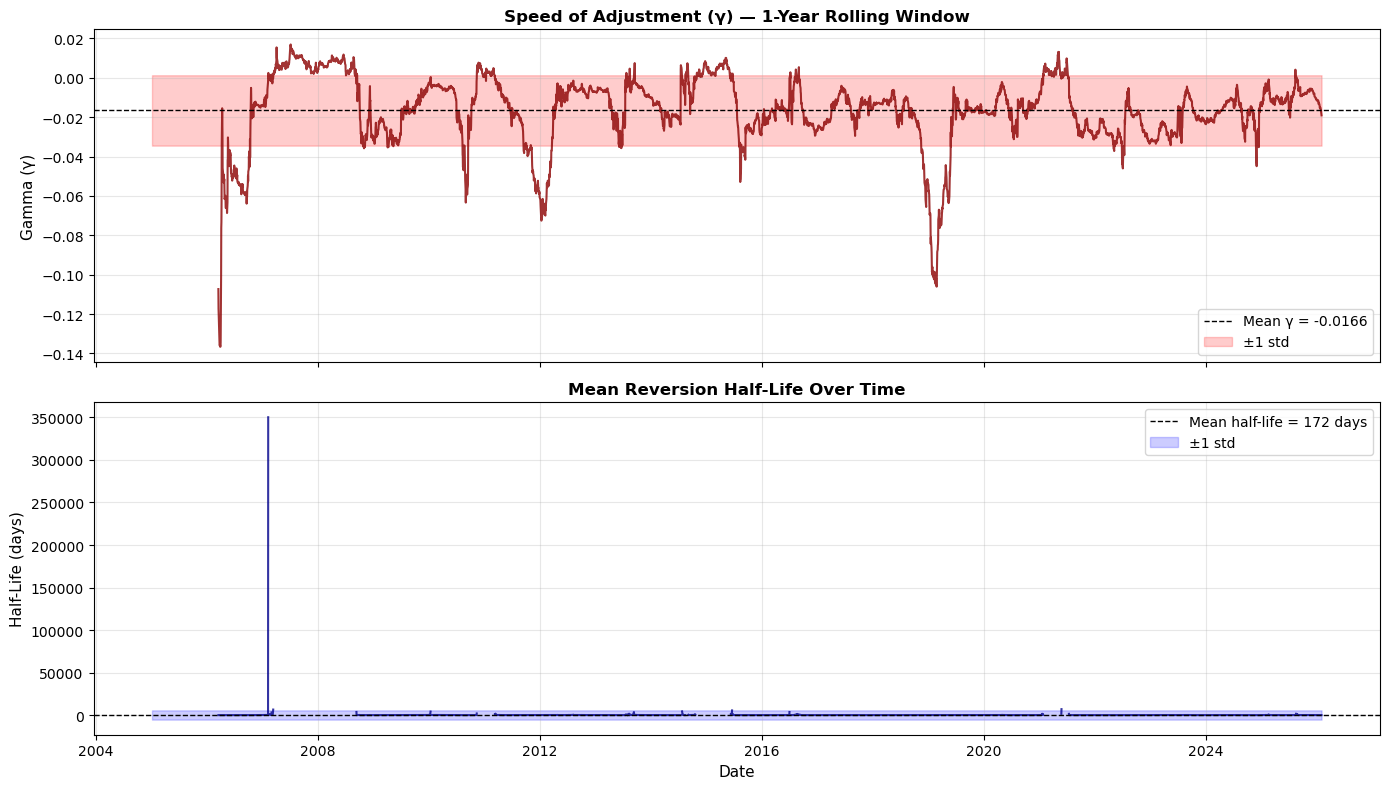

In [53]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Rolling Window Gamma (Speed of Adjustment) Estimation

WINDOW = 252  # 1 trading year (same as beta estimation)

print("Estimating gamma with 1-year rolling window (no look-ahead bias)...")
print(f"Window size: {WINDOW} trading days\n")

# Prepare ECM variables
dy = np.log(data['corn_Close']).diff() # delta of log price (return) for corn
dx = np.log(data['soybean_Close']).diff() # delta of log price (return) for soybean
spread_lag = data['ecm_spread'].shift(1) # yesterday's spread as lagged term for today's change in corn price

# Initialize results
data['gamma'] = np.nan
data['half_life'] = np.nan

# Rolling window estimation
for i in range(WINDOW + 1, len(data)):  # +1 because we need spread_lag (we shifted it by 1)
    # Training window: PAST 252 days
    train_dy = dy.iloc[i-WINDOW:i]
    train_dx = dx.iloc[i-WINDOW:i]
    train_spread_lag = spread_lag.iloc[i-WINDOW:i]
    
    # Create ECM dataframe for this window
    ecm_df = pd.DataFrame({
        'dy': train_dy,
        'dx': train_dx,
        'spread_lag': train_spread_lag
    }).dropna()
    
    if len(ecm_df) < 50:  # need enough data
        continue
    
    # Estimate gamma on training window
    X_ecm = sm.add_constant(ecm_df[['spread_lag', 'dx']])
    try:
        ecm_model = sm.OLS(ecm_df['dy'], X_ecm).fit()
        gamma_t = ecm_model.params['spread_lag']
    except:
        gamma_t = data['gamma'].iloc[i-1] if i > WINDOW + 1 else np.nan
    
    # Store gamma for this date
    current_idx = data.index[i]
    data.loc[current_idx, 'gamma'] = gamma_t
    
    # Compute half-life (only if gamma is negative)
    if gamma_t < 0:
        data.loc[current_idx, 'half_life'] = -np.log(2) / gamma_t
    else:
        data.loc[current_idx, 'half_life'] = np.nan

print(f"✓ Gamma estimation complete.\n")


# Summary Statistics

valid_gamma = data['gamma'].dropna()
valid_hl = data['half_life'].dropna()

print("=" * 80)
print("GAMMA STATISTICS (Rolling 1-Year Window)")
print("=" * 80)
print(f"Mean:   {valid_gamma.mean():.4f}")
print(f"Median: {valid_gamma.median():.4f}")
print(f"Std:    {valid_gamma.std():.4f}")
print(f"Min:    {valid_gamma.min():.4f}")
print(f"Max:    {valid_gamma.max():.4f}")

print(f"\n" + "=" * 80)
print("HALF-LIFE STATISTICS")
print("=" * 80)
print(f"Mean:   {valid_hl.mean():.1f} days")
print(f"Median: {valid_hl.median():.1f} days")
print(f"Std:    {valid_hl.std():.1f} days")
print(f"Min:    {valid_hl.min():.1f} days")
print(f"Max:    {valid_hl.max():.1f} days")

print(f"\nInterpretation:")
print(f"  On average, the spread half-life is {valid_hl.mean():.0f} days")
print(f"  Meaning: it takes ~{valid_hl.mean():.0f} trading days for half of a spread deviation to revert")

# Visualization

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Gamma over time
ax1.plot(data.index, data['gamma'], linewidth=1.5, color='darkred', alpha=0.8)
ax1.axhline(valid_gamma.mean(), color='black', linestyle='--', linewidth=1, 
            label=f'Mean γ = {valid_gamma.mean():.4f}')
ax1.fill_between(data.index,
                  valid_gamma.mean() - valid_gamma.std(),
                  valid_gamma.mean() + valid_gamma.std(),
                  alpha=0.2, color='red', label='±1 std')
ax1.set_ylabel('Gamma (γ)', fontsize=11)
ax1.set_title('Speed of Adjustment (γ) — 1-Year Rolling Window', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Bottom: Half-life over time
ax2.plot(data.index, data['half_life'], linewidth=1.5, color='darkblue', alpha=0.8)
ax2.axhline(valid_hl.mean(), color='black', linestyle='--', linewidth=1,
            label=f'Mean half-life = {valid_hl.mean():.0f} days')
ax2.fill_between(data.index,
                  valid_hl.mean() - valid_hl.std(),
                  valid_hl.mean() + valid_hl.std(),
                  alpha=0.2, color='blue', label='±1 std')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Half-Life (days)', fontsize=11)
ax2.set_title('Mean Reversion Half-Life Over Time', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 3 - Add lagged variables and replace daily observations with 2-month average

In [ ]:
# Step 6 — Add Lagged Variables & Replace Daily with 60-Day Weather Averages

print("Step 6: Adding lagged features and smoothing weather with 60-day averages...\n")

# 60-Day Weather Averages

WEATHER_WINDOW = 60  # ~2 months of trading days

print(f"Replacing daily weather with {WEATHER_WINDOW}-day rolling averages...")

# Identify all weather columns
weather_cols = [c for c in data.columns if any(
    keyword in c for keyword in [
        'soil_temperature', 'soil_moisture', 'temperature_2m', 
        'precipitation', 'dew_point', 'cloud_cover', 'wind_speed',
        'surface_pressure', 'wet_bulb', 'apparent_temperature'
    ]
)]

print(f"Found {len(weather_cols)} weather features to smooth")

# Replace with 60-day rolling averages (overwrites original columns)
for col in weather_cols:
    data[col] = data[col].rolling(window=WEATHER_WINDOW, min_periods=30).mean()

print(f"✓ All {len(weather_cols)} weather features now use 60-day averages\n")

# Lagged Variables

print("Adding lagged features...")

# Spread lags
data['ecm_spread_lag1'] = data['ecm_spread'].shift(1)
data['ecm_spread_lag2'] = data['ecm_spread'].shift(2)
data['ecm_spread_lag5'] = data['ecm_spread'].shift(5)

# Return lags
data['corn_return_lag1'] = data['corn_log_return'].shift(1)
data['soy_return_lag1'] = data['soybean_log_return'].shift(1)

# Spread change (momentum)
data['spread_change'] = data['ecm_spread'].diff()
data['spread_change_lag1'] = data['spread_change'].shift(1)

# Spread return
data['spread_return'] = data['corn_log_return'] - data['soybean_log_return']

print("✓ Added 8 lagged/derived features\n")

# Drop Early Rows with Insufficient History

print("Removing rows with insufficient history...")

# Need at least:
# - 252 days for rolling beta
# - 60 days for weather averages  
# - 5 days for lag5
# Total: ~317 days minimum

MIN_VALID_IDX = 317

data_before = len(data)
data = data.iloc[MIN_VALID_IDX:].copy()
data_after = len(data)

print(f"✓ Dropped first {data_before - data_after} rows (insufficient history)")
print(f"  Remaining: {data_after} rows")

# Drop _locnan columns (artifact from pivot with missing Location_ID)

locnan_cols = [c for c in data.columns if 'locnan' in c]

if locnan_cols:
    print(f"\nRemoving {len(locnan_cols)} _locnan columns (pivot artifacts)...")
    data = data.drop(columns=locnan_cols)
    print(f"✓ Dropped _locnan columns")
else:
    print("\nNo _locnan columns found")

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")


Step 6: Adding lagged features and smoothing weather with 60-day averages...

Replacing daily weather with 60-day rolling averages...
Found 104 weather features to smooth
✓ All 104 weather features now use 60-day averages

Adding lagged features...
✓ Added 8 lagged/derived features

Removing rows with insufficient history...
✓ Dropped first 317 rows (insufficient history)
  Remaining: 4671 rows

Removing 39 _locnan columns (pivot artifacts)...
✓ Dropped _locnan columns
Dataset shape: (4671, 136)
Date range: 2007-07-10 to 2026-02-02


## Step 4 — Triple barrier method
Chapter 3 of "Advances in Financial Machine Learning"

Key fix: barriers are now set on the ECM residual spread (not the raw log-ratio).
Raw log-ratio is not stationary. 

In [60]:
# Volatility of the ECM spread (EWMA, span=100)
def get_daily_vol(series, span=100):
    """Exponentially-weighted std of daily changes in the spread."""
    return series.diff().ewm(span=span).std()


daily_vol = get_daily_vol(data['ecm_spread'])


# Vertical barriers (max holding period = 60 trading days)
# FIX: clip instead of drop — last rows get the final available date.
t1_indices = data.index.searchsorted(data.index + pd.Timedelta(days=60))
t1_indices = np.clip(t1_indices, 0, len(data.index) - 1)   # safe clip
t1 = pd.Series(data.index[t1_indices], index=data.index)


# apply_pt_sl_on_t1
def apply_pt_sl_on_t1(close, events, pt_sl, molecule):
    """
    Scan each event's price path and record when (if ever) the
    profit-take (pt) or stop-loss (sl) barrier is first breached.

    Parameters
    ----------
    close     : spread series
    events    : DataFrame with columns ['t1', 'trgt', 'side']
    pt_sl     : [sl_multiplier, pt_multiplier]
    molecule  : index subset to process
    """
    events_ = events.loc[molecule]
    out = events_[['t1']].copy(deep=True)

    pt = pt_sl[1] * events_['trgt'] if pt_sl[1] > 0 else pd.Series(np.nan, index=events_.index)
    sl = -pt_sl[0] * events_['trgt'] if pt_sl[0] > 0 else pd.Series(np.nan, index=events_.index)

    for loc, t1_val in events_['t1'].fillna(close.index[-1]).items():
        path = close[loc:t1_val]
        path = path - close[loc]           # cumulative change from entry
        out.loc[loc, 'sl'] = path[path < sl[loc]].index.min()
        out.loc[loc, 'pt'] = path[path > pt[loc]].index.min()

    return out


# get_events
def get_events(close, t_events, pt_sl, target, min_ret,
               vertical_barrier_times=False, side=None):
    """
    Build an events DataFrame and apply the triple barrier.
    """
    # Filter on minimum volatility
    target = target.loc[t_events]
    target = target[target > min_ret]

    # Vertical barrier
    t1 = vertical_barrier_times if vertical_barrier_times is not False \
         else pd.Series(pd.NaT, index=t_events)

    # Side (default: always long, i.e. 1.0)
    side_ = side.loc[target.index] if side is not None \
            else pd.Series(1.0, index=target.index)

    # Align indices
    common_idx = target.index.intersection(t1.index).intersection(side_.index)
    events = pd.DataFrame({
        't1':   t1.loc[common_idx],
        'trgt': target.loc[common_idx],
        'side': side_.loc[common_idx],
    }).dropna(subset=['trgt'])

    # Apply barriers
    df0 = apply_pt_sl_on_t1(close=close, events=events,
                             pt_sl=pt_sl, molecule=events.index)

    # First barrier touched
    events['t1'] = df0.dropna(how='all').min(axis=1)

    return events


# Run triple barrier
events = get_events(
    close=data['ecm_spread'],    # FIX: use ECM residual spread
    t_events=data.index,
    pt_sl=[1, 1],                # symmetric ±1σ barriers
    target=daily_vol,
    min_ret=0.005,
    vertical_barrier_times=t1,
)

print(f"Events generated: {events.shape}")

Events generated: (4667, 3)


## Step 5 — Label Generation

Key fix: vertical barrier (time-out) is now correctly labelled 0 instead of ±1.

In [61]:
def get_bins(events, close, t1_original):
    """
    Label each event based on which barrier was hit first.

    Returns a DataFrame with:
        ret : realised change in spread from entry to first barrier touch
        bin : +1 (PT hit), -1 (SL hit), 0 (vertical barrier / time-out)

    Parameters
    ----------
    events      : output of get_events
    close       : spread series
    t1_original : the original vertical barrier Series (before overwriting in get_events)
                  used to identify which events timed out
    """
    events_ = events.dropna(subset=['t1'])

    entry_spread = close.loc[events_.index]
    exit_spread  = close.loc[events_['t1']]

    out = pd.DataFrame(index=events_.index)
    out['ret'] = exit_spread.values - entry_spread.values   # change in spread
    out['bin'] = np.sign(out['ret'])                        # raw direction

    # FIX: override with 0 where the vertical barrier was hit
    # i.e. the first-touch time equals the original vertical barrier time
    vertical_hit = events_['t1'] == t1_original.loc[events_.index]
    out.loc[vertical_hit, 'bin'] = 0

    return out


labels = get_bins(events, data['ecm_spread'], t1)

print("Label distribution:")
print(labels['bin'].value_counts().sort_index())

Label distribution:
bin
-1.0    2413
 0.0      10
 1.0    2244
Name: count, dtype: int64


## Step 6 — Export Final Dataset for Feature Selection

Joins the wide-format feature matrix with triple barrier labels. This is the input for the next stage.

In [62]:
# Add ECM spread
data['ecm_spread_lag1'] = data['ecm_spread'].shift(1)
data['ecm_spread_lag2'] = data['ecm_spread'].shift(2)
data['spread_return']   = data['corn_log_return'] - data['soybean_log_return']

# Merge labels in
feature_df = data.join(labels[['bin', 'ret']], how='inner')
feature_df = feature_df.dropna(subset=['bin'])

print(f"Final feature matrix shape: {feature_df.shape}")
print(f"Label distribution:\n{feature_df['bin'].value_counts().sort_index()}")

# Save to CSV for next stage
feature_df.to_csv("C:\\Users\\roosd\\Downloads\\econometrie jaar 3\\TIC\\Spring2026-TIC\\data\\feature_matrix.csv")
print("\nSaved to feature_matrix.csv — ready for feature selection.")

Final feature matrix shape: (4667, 138)
Label distribution:
bin
-1.0    2413
 0.0      10
 1.0    2244
Name: count, dtype: int64

Saved to feature_matrix.csv — ready for feature selection.
